In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import nnls, minimize

df = pd.read_csv("data.csv", index_col=0)
df

,PSC,JUNTS,ERC,PP,VOX,COMUNS,CUP,ALIANÇA.CAT,Altres,Cs,Abstenció
1980,0.138185,0.171275,0.054873,0.014556,0.000000,0.115557,0.000000,0.000000,0.117144,0.000000,0.388410
1984,0.193811,0.301318,0.028411,0.049647,0.000000,0.035962,0.000000,0.000000,0.031802,0.000000,0.359048
1988,0.177197,0.272179,0.024616,0.031648,0.000000,0.046166,0.000000,0.000000,0.039541,0.000000,0.408652
1992,0.152089,0.255296,0.043962,0.032968,0.000000,0.035913,0.000000,0.000000,0.025621,0.000000,0.454152
1995,0.159822,0.263467,0.061096,0.084246,0.000000,0.062607,0.000000,0.000000,0.005756,0.000000,0.363006
1999,0.227821,0.226843,0.052261,0.057211,0.000000,0.015129,0.000000,0.000000,0.016845,0.000000,0.403890
2003,0.198586,0.196993,0.104874,0.075627,0.000000,0.046480,0.000000,0.000000,0.008517,0.000000,0.368922
2006,0.153722,0.180767,0.080571,0.060980,0.000000,0.054760,0.000000,0.000000,0.013357,0.017425,0.438418
2010,0.111491,0.234199,0.042640,0.075148,0.000000,0.044927,0.000000,0.000000,0.061473,0.020696,0.409426
2012,0.101217,0.215104,0.095984,0.091014,0.000000,0.069380,0.024398,0.000000,0.040548,0.053099,0.309256


In [2]:
df.drop(columns=["VOX", "ALIANÇA.CAT"], inplace=True)
df

,PSC,JUNTS,ERC,PP,COMUNS,CUP,Altres,Cs,Abstenció
1980,0.138185,0.171275,0.054873,0.014556,0.115557,0.000000,0.117144,0.000000,0.388410
1984,0.193811,0.301318,0.028411,0.049647,0.035962,0.000000,0.031802,0.000000,0.359048
1988,0.177197,0.272179,0.024616,0.031648,0.046166,0.000000,0.039541,0.000000,0.408652
1992,0.152089,0.255296,0.043962,0.032968,0.035913,0.000000,0.025621,0.000000,0.454152
1995,0.159822,0.263467,0.061096,0.084246,0.062607,0.000000,0.005756,0.000000,0.363006
1999,0.227821,0.226843,0.052261,0.057211,0.015129,0.000000,0.016845,0.000000,0.403890
2003,0.198586,0.196993,0.104874,0.075627,0.046480,0.000000,0.008517,0.000000,0.368922
2006,0.153722,0.180767,0.080571,0.060980,0.054760,0.000000,0.013357,0.017425,0.438418
2010,0.111491,0.234199,0.042640,0.075148,0.044927,0.000000,0.061473,0.020696,0.409426
2012,0.101217,0.215104,0.095984,0.091014,0.069380,0.024398,0.040548,0.053099,0.309256


In [3]:
list(df.columns)

['PSC', 'JUNTS', 'ERC', 'PP', 'COMUNS', 'CUP', 'Altres', 'Cs', 'Abstenció']

Model successfully fitted using time weights (Decay Rate: 0.1)
Applied weights per step (oldest to newest): [0.51 0.57 0.63 0.69 0.76 0.84 0.93 1.03 1.14 1.26 1.39 1.54 1.7 ]
Stable Markov Chain Model (14 Years, 9 Parties)
Global Transition Matrix (Rows = From Party, Columns = To Party):
              PSC   JUNTS     ERC      PP  COMUNS     CUP  Altres      Cs  Abstenció
PSC        0.8335  0.0096  0.0013  0.0000  0.0020  0.0000  0.0000  0.0000     0.1536
JUNTS      0.0000  0.6457  0.1019  0.0000  0.0030  0.0162  0.0000  0.0098     0.2233
ERC        0.0002  0.0000  0.6286  0.0000  0.0000  0.0000  0.0000  0.0008     0.3704
PP         0.0000  0.0070  0.0386  0.8563  0.0006  0.0000  0.0000  0.0974     0.0000
COMUNS     0.0223  0.0138  0.0016  0.0000  0.8645  0.0000  0.0000  0.0063     0.0915
CUP        0.0098  0.0000  0.0036  0.0000  0.0000  0.9363  0.0000  0.0075     0.0427
Altres     0.0071  0.0359  0.0277  0.0000  0.0000  0.0004  0.8739  0.0549     0.0000
Cs         0.0000  0.0000  0.00

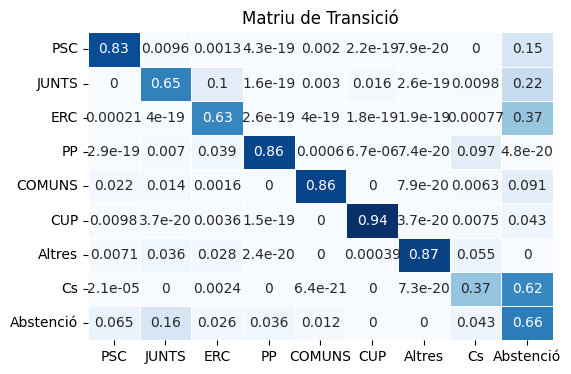

In [4]:
from utils import StableMarkovChain

mc = StableMarkovChain(df)
mc.fit(df)

print(mc)
mc.plot_transition_matrix()

PSC          1.536451e-01
JUNTS        1.704251e-01
ERC          8.399904e-02
PP           9.368689e-02
COMUNS       3.915264e-02
CUP          4.348282e-02
Altres       1.240849e-17
Cs           4.395980e-02
Abstenció    3.716486e-01
dtype: float64


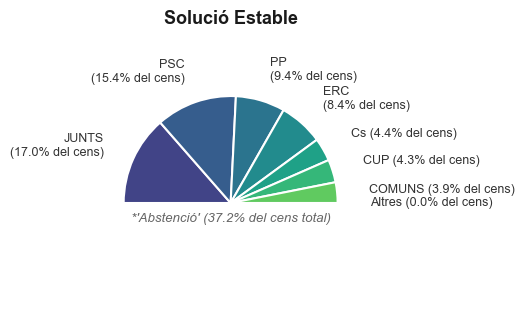

In [5]:
print(mc.get_steady_state())
mc.plot_steady_state()

In [6]:
df = df.iloc[-len(df.columns):]

# Dades numèriques
dades = df.values

# Partits
partits = df.columns
n = len(partits)

print("Partits:", list(partits))

# X_t ≈ P * X_{t+1}
A = dades[1:]   # futur
B = dades[:-1]  # passat

P_llista = []

# Intensitat de la penalització
lambda_transvas = 0.05

for j in range(n):

    b = B[:, j]

    # Funció objectiu
    def objectiu(p):

        # Error quadràtic
        error = np.sum((A @ p - b) ** 2)

        # Penalització dels transvasaments
        mask = np.arange(n) != j

        penalitzacio = lambda_transvas * np.sum(p[mask] ** 2)

        return error + penalitzacio

    # Valor inicial
    p0 = np.ones(n) / n

    # Restricció: p_i >= 0
    bounds = [(0, None)] * n

    # Optimització
    resultat = minimize(
        objectiu,
        p0,
        bounds=bounds,
        method='L-BFGS-B'
    )

    p_opt = resultat.x

    # Normalitzar perquè sumi 1
    if p_opt.sum() > 0:
        p_opt = p_opt / p_opt.sum()

    P_llista.append(p_opt)

# Construcció matriu final
P_est = np.array(P_llista).T

df_P_final = pd.DataFrame(
    P_est,
    index=partits,
    columns=partits
)

print("\nMatriu de Transició amb fidelitat partidista:")
print(df_P_final.round(3).to_string())

Partits: ['PSC', 'JUNTS', 'ERC', 'PP', 'COMUNS', 'CUP', 'Altres', 'Cs', 'Abstenció']

Matriu de Transició amb fidelitat partidista:
             PSC  JUNTS    ERC     PP  COMUNS    CUP  Altres     Cs  Abstenció
PSC        0.906  0.029  0.000  0.000   0.000  0.008   0.004  0.000      0.112
JUNTS      0.063  0.729  0.000  0.062   0.000  0.000   0.058  0.000      0.247
ERC        0.000  0.088  0.686  0.056   0.020  0.048   0.073  0.056      0.006
PP         0.018  0.000  0.000  0.720   0.000  0.000   0.054  0.000      0.156
COMUNS     0.000  0.028  0.000  0.033   0.796  0.000   0.046  0.000      0.055
CUP        0.000  0.037  0.044  0.022   0.032  0.871   0.044  0.073      0.000
Altres     0.013  0.000  0.000  0.003   0.017  0.000   0.638  0.000      0.040
Cs         0.000  0.041  0.047  0.101   0.087  0.065   0.082  0.734      0.027
Abstenció  0.000  0.048  0.223  0.002   0.049  0.008   0.000  0.137      0.357


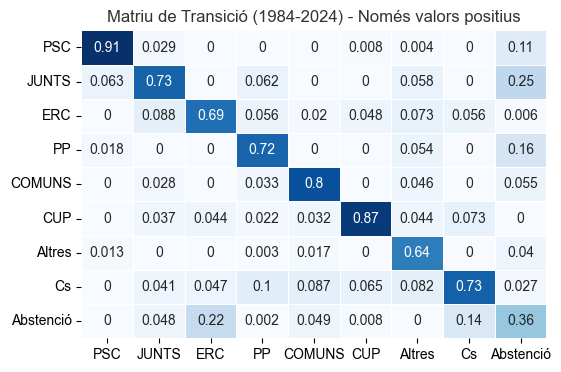

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
sns.heatmap(df_P_final.round(3), annot=True, cmap="Blues", cbar=False, linewidths=0.5)
plt.title("Matriu de Transició (1984-2024) - Només valors positius")
plt.show()

In [8]:
import numpy as np

eigenvalues, eigenvectors = np.linalg.eig(df_P_final)

# Trobar l'índex de l'autovalor més proper a 1
idx = np.argmin(np.abs(eigenvalues - 1))

# Extreure el vector i normalitzar (suma = 1)
pi = np.real(eigenvectors[:, idx])
pi = pi / pi.sum()

partits = list(df_P_final.columns)
for p, v in zip(partits, pi):
    print(f"{p:10s}: {v:.4f}")

###### COMPROVACIÓ DE LA DISTRIBUCIÓ ESTACIONÀRIA ######
print("\nComprovació de la distribució estacionària:")
print(np.allclose(df_P_final @ pi, pi))  # Ha de donar True
print(pi.sum())                    # Ha de donar 1.0

PSC       : 0.1682
JUNTS     : 0.1394
ERC       : 0.1165
PP        : 0.0647
COMUNS    : 0.0582
CUP       : 0.1963
Altres    : 0.0189
Cs        : 0.1483
Abstenció : 0.0895

Comprovació de la distribució estacionària:
True
1.0
